In [60]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import copy

import itertools
import random

In [61]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 2) 
        if len(parts) < 2: continue
        
        terrain, sensor = f"{parts[0]}_{parts[1]}", parts[2]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 6 terrains from walking_terrain_datasets.npz


In [62]:
# print(dataset.keys())
# print(dataset['solid_ground'].keys())
# print(dataset['soft_ground']['joint_velocity_fb'])

In [63]:
# import numpy as np

# # 1. Select a terrain and a sensor we know has an extra column
# terrain = 'solid_ground'
# sensor = 'cpg_output'

# # 2. Extract the very first gait cycle (index 0)
# sample_cycle = np.array(dataset[terrain][sensor][0])

# print(f"🔍 INSPECTING: {terrain} -> {sensor}")
# print(f"Shape: {sample_cycle.shape[0]} timesteps, {sample_cycle.shape[1]} features\n")

# # 3. Print the first 10 timesteps nicely formatted
# np.set_printoptions(suppress=True, precision=5) # Prevent scientific notation

# print("Row | Col 0      Col 1      Col 2      Col 3      Col 4")
# print("-" * 60)
# for i in range(10):
#     row_data = sample_cycle[i, :]
#     # Format each number to have 5 decimal places for easy reading
#     formatted_row = "  ".join([f"{val:9.5f}" for val in row_data])
#     print(f"{i:3d} | {formatted_row}")

In [64]:
def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
	"""
	Splits the gait cycle dataset into training and testing sets.
	Safely handles sensors with mismatched cycle counts.
	"""
	random.seed(seed)
	train_set = {}
	test_set = {}

	for terrain in dataset.keys():
		# 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
		# This ensures we don't try to access an index that doesn't exist for a sensor
		sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
		if not sensor_counts:
			continue
			
		min_cycles = min(sensor_counts)
		
		# 2. Generate indices based on the shortest sensor stream
		indices = list(range(min_cycles))
		random.shuffle(indices)
		
		split_idx = int(min_cycles * train_ratio)
		train_indices = indices[:split_idx]
		test_indices = indices[split_idx:]
		
		train_set[terrain] = {}
		test_set[terrain] = {}

		# 3. Distribute cycles
		for sensor in dataset[terrain].keys():
			all_cycles = dataset[terrain][sensor]
			# We only take the cycles up to min_cycles to stay synchronized
			train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
			test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
			
		print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
			  f"({len(train_indices)} train, {len(test_indices)} test)")

	return train_set, test_set

def split_and_roll_gait_dataset(dataset, train_ratio=0.8, num_rolls=3, augment_test=True, seed=42):
    """
    Splits the dataset and safely applies 'rolling' augmentation to prevent data leakage.
    
    Args:
        dataset: The nested dictionary containing terrain -> sensor -> cycles.
        train_ratio: Percentage of data to use for training.
        num_rolls: How many additional phase-shifted cycles to generate per original cycle. 
                   (e.g., num_rolls=3 creates shifts at 25%, 50%, and 75% of the cycle length)
        augment_test: If True, applies rolling to the test set as well. Usually kept False.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # Initialize dictionaries for this terrain
        train_set[terrain] = {s: [] for s in dataset[terrain].keys()}
        test_set[terrain]  = {s: [] for s in dataset[terrain].keys()}
        
        # 1. FIND THE MINIMUM CYCLE COUNT (Synchronization Check)
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        sensors = list(dataset[terrain].keys())
        
        # 2. SPLIT INDICES FIRST (To prevent data leakage)
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        # 3. HELPER FUNCTION TO ROLL DATA
        def extract_and_roll(target_dict, index_list, apply_rolling):
            for i in index_list:
                # Find the length of this specific gait cycle (assuming all sensors share the same length for cycle 'i')
                cycle_len = len(dataset[terrain][sensors[0]][i])
                
                # Calculate the exact array indices to shift by.
                # If num_rolls=3, shifts = [0, 25%, 50%, 75% of cycle length]
                if apply_rolling:
                    shifts = [int(cycle_len * (j / (num_rolls + 1))) for j in range(num_rolls + 1)]
                else:
                    shifts = [0] # Only keep the original, unshifted cycle
                
                # Apply the shifts to every sensor so they stay perfectly synchronized
                for shift in shifts:
                    for sensor in sensors:
                        cycle_data = dataset[terrain][sensor][i]
                        
                        # Apply Left-Shift Phase Rolling
                        if isinstance(cycle_data, list):
                            rolled_cycle = cycle_data[shift:] + cycle_data[:shift]
                        else:
                            # Fallback just in case your data is stored as Numpy arrays
                            rolled_cycle = np.roll(cycle_data, -shift, axis=0) 
                            
                        target_dict[sensor].append(copy.deepcopy(rolled_cycle))

        # 4. EXTRACT AND AUGMENT
        # Augment the training set
        extract_and_roll(train_set[terrain], train_indices, apply_rolling=True)
        
        # Extract the testing set (Un-augmented by default)
        extract_and_roll(test_set[terrain], test_indices, apply_rolling=augment_test)

        # Print detailed diagnostic readout
        train_count = len(train_set[terrain][sensors[0]])
        test_count = len(test_set[terrain][sensors[0]])
        
        print(f"Terrain {terrain.upper()}:")
        print(f" -> Original unique cycles: {min_cycles}")
        print(f" -> TRAIN set grew to {train_count} cycles (Augmented {num_rolls}x)")
        print(f" -> TEST set contains {test_count} cycles (Original only)\n")

    return train_set, test_set


In [65]:
def flatten_datasets(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
				# --- ADD THIS PRINT STATEMENT TO DEBUG ---
				# if i == 0:  # Only print for the very first cycle so it doesn't spam your terminal
				# 	print(f"Sensor '{sensor_name}' contributes {sensor_array.shape[1]} features.")
				# # ---------------------------------------
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
            
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

def robust_flatten_datasets(data, labels_dict, sensor_keys):
    """
    Safely extracts and merges multiple sensor features from the dataset.
    Handles both single strings and lists of strings.
    """
    X, y = [], []
    
    # Ensure sensor_keys is a list so we can iterate over it
    if isinstance(sensor_keys, str):
        sensor_keys = [sensor_keys]
        
    for terrain, label in labels_dict.items():
        if terrain not in data:
            print(f"Warning: Terrain '{terrain}' not found in data.")
            continue
            
        # Use the first sensor to determine the number of gait cycles
        first_sensor = sensor_keys[0]
        if first_sensor not in data[terrain]:
            print(f"Warning: Sensor '{first_sensor}' not found in terrain '{terrain}'.")
            continue
            
        num_cycles = len(data[terrain][first_sensor])
        
        for i in range(num_cycles):
            cycle_features = []
            for s in sensor_keys:
                # Extract the shape (time_steps, features) array for this specific sensor and cycle
                cycle_features.append(data[terrain][s][i])
            
            # Concatenate all sensor features for this cycle along the column (feature) axis
            merged_cycle = np.concatenate(cycle_features, axis=-1)
            X.append(merged_cycle)
            y.append(label)
            
    return X, y

In [66]:
from models.model_1_esn_rr.env_pred import ESN_RR_Classification, ESN_RR_Classification_No_mean
from models.model_2_haptr.env_pred import HAPTR_Classifier
from models.model_3_cnn_rnn.env_pred import CNN_RNN_Classifier
from models.model_4_tcn.env_pred import TCN_Classifier

TERRAIN_LABELS = {
    'solid_ground'      : 0,
    'soft_ground'       : 1,
    'slippery_ground'   : 2,
    'rough_ground'      : 3,
    'muddy_ground'      : 4,
    'water_surface'     : 5
}

# Define a list of ALL the different sensor configurations you want to test
sensor_list = [
	# ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'], # config_1
	['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'], # config_2
	['joint_torque_fb'],	# config_3
 
    # ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],  # config_7
    ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],  # config_8
    ['joint_torque_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],  # config_6
    
]


# The sensor configurations
model_list = ['config_2', 'config_3', 'config_8', 'config_6']
model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn']
model_arch_obj_list = {}
for model_arch in model_arch_list:
	if model_arch == 'esn':
		model_arch_obj_list[model_arch] = ESN_RR_Classification()
	if model_arch == 'haptr':
		model_arch_obj_list[model_arch] = HAPTR_Classifier()
	if model_arch == 'cnn_rnn':
		model_arch_obj_list[model_arch] = CNN_RNN_Classifier()
	if model_arch == 'tcn':
		model_arch_obj_list[model_arch] = TCN_Classifier()



In [67]:
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

Splitting dataset...
Terrain SOLID_GROUND: Used 569 synchronized cycles. (284 train, 285 test)
Terrain SOFT_GROUND: Used 569 synchronized cycles. (284 train, 285 test)
Terrain SLIPPERY_GROUND: Used 569 synchronized cycles. (284 train, 285 test)
Terrain ROUGH_GROUND: Used 569 synchronized cycles. (284 train, 285 test)
Terrain MUDDY_GROUND: Used 569 synchronized cycles. (284 train, 285 test)
Terrain WATER_SURFACE: Used 569 synchronized cycles. (284 train, 285 test)


In [68]:
import numpy as np
import json
from scipy import stats
from sklearn.preprocessing import StandardScaler

# ==========================================
# 0. NOISE AUGMENTATION FUNCTION
# ==========================================
def simulate_sensor_noise_ptp(X_data, noise_level=0.10, seed=42):
    """Simulates noise scaled to the Peak-to-Peak (Full-Scale) range of the sensor."""
    np.random.seed(seed)
    X_noisy = []
    for cycle in X_data:
        noisy_cycle = cycle.copy()
        feature_scales = np.ptp(noisy_cycle, axis=0)
        feature_scales[feature_scales == 0] = 1.0 
        
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        scaled_noise = standard_normal_noise * (noise_level * feature_scales)
        
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
    return X_noisy

# ==========================================
# 1. BOOTSTRAP SETUP
# ==========================================
ORIGINAL_TRAIN_SEED = 42 
N_BOOTSTRAP = 100          
EVAL_NOISE_LEVEL = 0.20  # 15% harsh noise for robustness testing

# Trackers
raw_predictions = {}       
seed_acc_tracker = {}      
accuracy_dict = {}

# Pre-populate structures
for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    seed_acc_tracker[model_arch_name] = {}
    raw_predictions[model_arch_name] = {}
    for model_file in model_list:
        seed_acc_tracker[model_arch_name][model_file] = []

# ==========================================
# 2. LOCK THE CLEAN HOLDOUT TEST SET
# ==========================================
print(f"=========================================")
print(f"LOCKING TEST SET (SEED: {ORIGINAL_TRAIN_SEED})")
print(f"=========================================")

# Split ONCE using the original seed
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.8, seed=ORIGINAL_TRAIN_SEED)

# ==========================================
# 3. GET RAW PREDICTIONS ON NOISY TEST SET
# ==========================================
for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'

    for sensor_key, model_file in zip(sensor_list, model_list):
        model_file_name = model_file
        print(f"  -> Evaluating: {model_arch_name} | {model_file_name} with {EVAL_NOISE_LEVEL*100}% Noise")
        
        # 1. Extract clean test data
        X_train, y_train = flatten_datasets(train_data, TERRAIN_LABELS, sensor_key)
        X_test, y_test = flatten_datasets(test_data, TERRAIN_LABELS, sensor_key)

        # 🚨 INJECT NOISE INTO THE TEST SET HERE 🚨
        X_test_noisy = simulate_sensor_noise_ptp(X_test, noise_level=EVAL_NOISE_LEVEL, seed=99)

        # 2. Conditional Scaling (Using the NOISY test set)
        if model_arch in ['cnn_rnn', 'tcn']:
            X_train_np = np.array(X_train)
            X_test_np = np.array(X_test_noisy) # Use noisy data
            test_shape = X_test_np.shape
            
            X_train_2d = X_train_np.reshape(-1, X_train_np.shape[-1])
            X_test_2d = X_test_np.reshape(-1, test_shape[-1])
            
            scaler = StandardScaler()
            scaler.fit(X_train_2d)
            eval_X = scaler.transform(X_test_2d).reshape(test_shape)
        else:
            eval_X = X_test_noisy # Use noisy data directly

        # 3. Load model
        if model_arch in ['esn']:
            model_arch_obj_list[model_arch].load_model(f"trained_models_w_noise/model_1_{model_arch}_{model_file}_w_cma_es.pt")
        else:
            model_arch_obj_list[model_arch].load_model(f"trained_models_w_noise/model_1_{model_arch}_{model_file}.pt")

        # 4. Predict on the entire unseen NOISY test set
        y_pred = []
        for i in range(len(eval_X)):
            predicted_class, _ = model_arch_obj_list[model_arch].predict(eval_X[i])
            y_pred.append(predicted_class)

        # Save raw array predictions
        raw_predictions[model_arch_name][model_file_name] = {
            'y_true': np.array(y_test),
            'y_pred': np.array(y_pred)
        }

# ==========================================
# 4. BOOTSTRAP RESAMPLING (N = 100 Iterations)
# ==========================================
print(f"\n=========================================")
print(f"RUNNING {N_BOOTSTRAP} BOOTSTRAP RESAMPLES")
print(f"=========================================")

np.random.seed(244)  # Fixed seed for bootstrap sampling reproducibility
n_samples = len(y_test)

for b in range(N_BOOTSTRAP):
    # Sample test set indices WITH REPLACEMENT
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)

    for model_arch_name, configs in raw_predictions.items():
        for model_file_name, preds in configs.items():
            y_true_boot = preds['y_true'][boot_indices]
            y_pred_boot = preds['y_pred'][boot_indices]

            # Calculate accuracy on this bootstrapped sample
            acc = (np.sum(y_pred_boot == y_true_boot) / n_samples) * 100
            seed_acc_tracker[model_arch_name][model_file_name].append(acc)

# ==========================================
# 5. FINAL STATISTICAL CALCULATIONS
# ==========================================
print("\n=========================================")
print("FINAL BOOTSTRAP STATISTICAL RESULTS (NOISY)")
print("=========================================")

for model_arch_name, configs in seed_acc_tracker.items():
    accuracy_dict[model_arch_name] = {}
    
    for model_file_name, accuracies in configs.items():
        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)

        print(f"[RESULTS] {model_arch_name} ({model_file_name}): Mean = {mean_acc:.2f}%, Std = {std_acc:.2f}%")

        accuracy_dict[model_arch_name][model_file_name] = {
            'mean': mean_acc,
            'std': std_acc
        }

# Saved under a new filename so it doesn't overwrite your clean baseline results
output_filename = 'raw_seed_accuracies_for_paper_noisy.json'
with open(output_filename, 'w') as f:
    json.dump(seed_acc_tracker, f, indent=4)

print(f"\n[SUCCESS] Noisy bootstrapped statistical results saved to '{output_filename}'!")

LOCKING TEST SET (SEED: 42)
Terrain SOLID_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain SOFT_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain SLIPPERY_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain ROUGH_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain MUDDY_GROUND: Used 569 synchronized cycles. (455 train, 114 test)
Terrain WATER_SURFACE: Used 569 synchronized cycles. (455 train, 114 test)
  -> Evaluating: ESN | config_2 with 20.0% Noise

[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_2_w_cma_es.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 4832 neurons
   • Leak Rate:              0.6431344002717254
   • Target Classes:         6
   • Ignore Time Column:     True
   • Pooling Strategy:       'mean'

⚙️ Matrix Shapes:
   • W_in  (Input -> Res):   (4832, 14)
   • W_res (Res Dynamics):   (4832, 4832)
   • W_out (Res -> Out

# Summary

In [69]:
print("\nFinal Accuracy Comparison:", accuracy_dict)


Final Accuracy Comparison: {'ESN': {'config_2': {'mean': 77.53801169590643, 'std': 1.5981237502835006}, 'config_3': {'mean': 67.26315789473684, 'std': 1.8406752083959825}, 'config_8': {'mean': 93.62426900584798, 'std': 0.9584434500770804}, 'config_6': {'mean': 90.91520467836257, 'std': 0.9447702803670052}}, 'HAPTR': {'config_2': {'mean': 68.3172514619883, 'std': 1.8808347424322909}, 'config_3': {'mean': 60.64327485380117, 'std': 1.956881038801419}, 'config_8': {'mean': 86.84356725146198, 'std': 1.224670698664294}, 'config_6': {'mean': 87.02777777777776, 'std': 1.3100679698262943}}, 'CNN-RNN': {'config_2': {'mean': 87.31286549707603, 'std': 1.2794828507554843}, 'config_3': {'mean': 61.473684210526315, 'std': 1.8184548809255359}, 'config_8': {'mean': 95.40350877192981, 'std': 0.7772829626824895}, 'config_6': {'mean': 95.74707602339181, 'std': 0.7132630254661635}}, 'TCN': {'config_2': {'mean': 78.3845029239766, 'std': 1.7057557056253247}, 'config_3': {'mean': 53.30555555555555, 'std': 1.

## Accuracy

### Plot 2

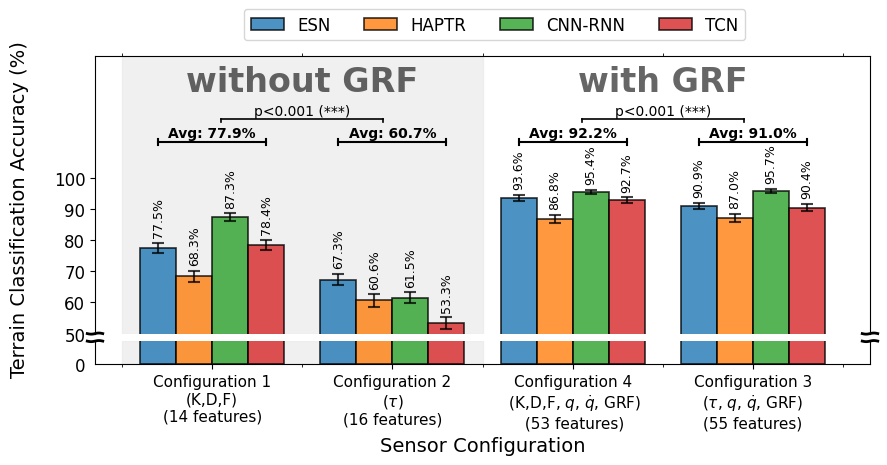

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy import stats

# --- Your existing setup ---
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linestyle': '--'}
}

# config_mapping = {
#     # 'config_1': 'Configuration 1\n(48 features)',

#     # 'config_7': 'Configuration 7\n(12 features)',
#     'config_2': 'Configuration 2\n(K,D,F)\n(14 features)',
#     'config_3': 'Configuration 3\n($\\tau$)\n(16 features)', 
#     'config_6': 'Configuration 6\n($\\tau$, $q$, $\\dot{q}$, GRF)\n(55 features)',
#     'config_8': 'Configuration 8\n (K,D,F, $q$, $\\dot{q}$, GRF)\n (53 features)',
# }

config_mapping = {
    # 'config_1': 'Configuration 1\n(48 features)',

    # 'config_7': 'Configuration 7\n(12 features)',
    'config_2': 'Configuration 1\n(K,D,F)\n(14 features)',
    'config_3': 'Configuration 2\n($\\tau$)\n(16 features)', 
    'config_6': 'Configuration 3\n($\\tau$, $q$, $\\dot{q}$, GRF)\n(55 features)',
    'config_8': 'Configuration 4\n (K,D,F, $q$, $\\dot{q}$, GRF)\n (53 features)',
}


# 1. Load the raw seed data
with open('raw_seed_accuracies_for_paper_noisy.json', 'r') as f:
    raw_data = json.load(f)

# 2. Unpack your nested dict into DataFrames
df_mean = pd.DataFrame({model: {config: metrics['mean'] for config, metrics in configs.items()} for model, configs in accuracy_dict.items()})
df_std = pd.DataFrame({model: {config: metrics['std'] for config, metrics in configs.items()} for model, configs in accuracy_dict.items()})

df_mean = df_mean.rename(index=config_mapping)
df_std = df_std.rename(index=config_mapping)
model_colors = [styles[model]['color'] for model in df_mean.columns]

# ==========================================
# 3. SETUP BROKEN AXIS (ax1 = Top, ax2 = Bottom)
# ==========================================
# We use gridspec to make the top plot larger to hold the brackets
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 4), gridspec_kw={'height_ratios': [12, 1]})
fig.subplots_adjust(hspace=0.05)  # Minimize space between the two axes

group_width = 0.8

# Plot the exact same data on BOTH axes
for ax in (ax1, ax2):
    df_mean.plot(
        kind='bar', 
        width=group_width, 
        color=model_colors, 
        alpha=0.8, 
        edgecolor='black', 
        linewidth=1.2,
        yerr=df_std, 
        error_kw=dict(lw=1.5, capsize=4, capthick=1.5, alpha=0.75, ecolor='black'),
        ax=ax,
        legend=False 
    )
    ax.axvspan(-0.5, 1.5, color='#eaeaea', alpha=0.7, zorder=0)  # Grey background 

# ==========================================
# 4. SET BREAK LIMITS (0-10 & 88-100)
# ==========================================
ax2.set_ylim(0, 10)
ax1_bottom_limit = 88 # Starts at 88 to protect the 89.5% ESN bar

# Hide spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()
# ==========================================
# DRAW WAVY BREAK MARKS ("~") ON THE SPINES
# ==========================================
# d controls the width of the squiggle
d = 0.010  

# Create a small x-axis array just for the squiggle
x_wave = np.linspace(-d, d, 50)

# Generate one full sine wave cycle for the "~" shape
y_wave_base = np.sin(x_wave * (np.pi / d))

# Scale amplitudes based on the [12, 1] height ratio so they match visually
amp_ax1 = 0.002
amp_ax2 = 0.002 * 12  

y_wave_ax1 = amp_ax1 * y_wave_base
y_wave_ax2 = 1 + (amp_ax2 * y_wave_base)

kwargs = dict(color='black', clip_on=False, lw=2)

# 1. Top Axis (ax1) - Bottom Left & Bottom Right Spines
ax1.plot(x_wave, y_wave_ax1, transform=ax1.transAxes, **kwargs)
ax1.plot(1 + x_wave, y_wave_ax1, transform=ax1.transAxes, **kwargs)

# 2. Bottom Axis (ax2) - Top Left & Top Right Spines
ax2.plot(x_wave, y_wave_ax2, transform=ax2.transAxes, **kwargs)
ax2.plot(1 + x_wave, y_wave_ax2, transform=ax2.transAxes, **kwargs)
# ==========================================
# 5. DRAW SCALED ANNOTATIONS & BRACKETS 
# ==========================================
ax1.legend(fontsize=12, title_fontsize=12, ncol=5, bbox_to_anchor=(0.85, 1.2))

# Calculate exactly how many bars exist (Configs * Models)
num_configs = len(df_mean)
num_models = len(df_mean.columns)
total_bars = num_configs * num_models

# Slice ax1.patches to ONLY loop over the bars, ignoring the background highlight!
for i, p in enumerate(ax1.patches[:total_bars]):
    row_idx = i % num_configs
    col_idx = i // num_configs
    std_val = df_std.iloc[row_idx, col_idx]
    text_y = p.get_height() + std_val
    ax1.annotate(
        f"{p.get_height():.1f}%", 
        (p.get_x() + p.get_width() / 2., text_y), 
        ha='center', va='bottom', fontsize=9, color='black', 
        xytext=(0, 4), textcoords='offset points', rotation=90
    )

num_models = len(df_mean.columns)
bar_width = group_width / num_models
bracket_y_positions = [] 

global_max_h = max([df_mean.iloc[i, j] + df_std.iloc[i, j] for i in range(len(df_mean)) for j in range(num_models)])
# Set one universal bracket height for everything
universal_bracket_y = global_max_h + 15

for i in range(len(df_mean)):
    left_x = i - (group_width / 2) + (bar_width / 2)
    right_x = i + (group_width / 2) - (bar_width / 2)
    
            
    # Scaled down from +15 to +1.5 due to tight axis zooming
    bracket_y = universal_bracket_y 
    bracket_y_positions.append(bracket_y)
    
    ax1.plot([left_x , right_x], [bracket_y, bracket_y], color='black', lw=1.5)
    ax1.plot([left_x, left_x], [bracket_y - 0.008*bracket_y, bracket_y + 0.008*bracket_y], color='black', lw=1.5)
    ax1.plot([right_x, right_x], [bracket_y - 0.008*bracket_y, bracket_y + 0.008*bracket_y], color='black', lw=1.5)
    
    avg_val = df_mean.iloc[i].mean()
    ax1.text(i, bracket_y + 0.5, f"Avg: {avg_val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

comparisons = []
comparisons = [(0, 1), (2, 3)]
config_files = model_list

# Scaled down padding and step sizes
base_overbrace_y = max(bracket_y_positions) + 7.5 
y_step = 2.0  
max_used_y = base_overbrace_y

for (idx1, idx2) in comparisons:
    conf1_name = config_files[idx1]
    conf2_name = config_files[idx2]
    
    data1, data2 = [], []
    for model in styles.keys(): 
        if model in raw_data and conf1_name in raw_data[model] and conf2_name in raw_data[model]:
            data1.extend(raw_data[model][conf1_name]) 
            data2.extend(raw_data[model][conf2_name])
        
    t_stat, p_val = stats.ttest_rel(data1, data2)
    
    if p_val < 0.001: sig_text = "***"; p_text = f"p<0.001 ({sig_text})"
    elif p_val < 0.01: sig_text = "**"; p_text = f"p={p_val:.3f} ({sig_text})"
    elif p_val < 0.05: sig_text = "*";  p_text = f"p={p_val:.3f} ({sig_text})"
    else: sig_text = "ns"; p_text = f"p={p_val:.3f} ({sig_text})"
        
    span = abs(idx1 - idx2)
    if span == 1: level = 0
    elif span == 3: level = 1
    else: level = 2
        
    current_overbrace_y = base_overbrace_y + (level * y_step)
    if current_overbrace_y > max_used_y:
        max_used_y = current_overbrace_y
    
    ax1.plot([idx1+0.05, idx2-0.05], [current_overbrace_y, current_overbrace_y], color='black', lw=1.2)
    ax1.plot([idx1+0.05, idx1+0.05], [current_overbrace_y - 0.01*current_overbrace_y, current_overbrace_y], color='black', lw=1.2)
    ax1.plot([idx2-0.05, idx2-0.05], [current_overbrace_y - 0.01*current_overbrace_y, current_overbrace_y], color='black', lw=1.2)
    
    ax1.text((idx1 + idx2) / 2, current_overbrace_y + 0.2, p_text, ha='center', va='bottom', fontsize=10, color='black')

# ==========================================
# 6. FINAL FORMATTING
# ==========================================
# Dynamic upper limit based on the top-most bracket
# ax1.set_ylim(ax1_bottom_limit, max_used_y + 1.5)
ax1.set_ylim(ax1_bottom_limit, max_used_y + 20.0)
# Ticks for 0-10
ax2.set_yticks([0, 10])
ax2.set_yticklabels(['0', ''], fontsize=12)

# Ticks for 88-100 (Steps of 2 for granularity)
ax1_yticks = np.arange(50, 101, 10)
ax1.set_yticks(ax1_yticks)
ax1.set_yticklabels([str(tick) for tick in ax1_yticks], fontsize=12)

# --- ADD THESE TWO LINES TO DISABLE Y-AXIS DASHES ---
ax1.tick_params(axis='y', left=True)
ax2.tick_params(axis='y', left=False)
ax1.tick_params(axis='x', top=False)
ax2.tick_params(axis='x', top=False)

# x=0.5 centers it between Config 1 and Config 2. max_used_y + 3.5 puts it near the top.
ax1.text(0.5, max_used_y + 12, "without GRF", ha='center', va='center', fontsize=24, fontweight='bold', color='black', alpha=0.6)
ax1.text(2.5, max_used_y + 12, "with GRF", ha='center', va='center', fontsize=24, fontweight='bold', color='black', alpha=0.6)
# ------------------------------------------------------------

fig.supylabel('Terrain Classification Accuracy (%)', fontsize=14, x=0.04)
ax2.set_xlabel('Sensor Configuration', fontsize=14)
ax2.set_xticklabels(df_mean.index, rotation=0, fontsize=11)

ax1.set_ylabel('')
ax2.set_ylabel('')

plt.savefig('accuracy_barchart_zoomed.png', dpi=500, bbox_inches='tight')
plt.show()

# Model Size


[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_2_w_cma_es_mini.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 1166 neurons
   • Leak Rate:              0.4049090824053525
   • Target Classes:         6
   • Ignore Time Column:     True
   • Pooling Strategy:       'mean'

⚙️ Matrix Shapes:
   • W_in  (Input -> Res):   (1166, 14)
   • W_res (Res Dynamics):   (1166, 1166)
   • W_out (Res -> Output):  (6, 1166)

🛠️ System Config:
   • Scaler Initialized:     True
   • Expected Features:      14
   • Target Device:          CUDA
--------------------------------------------------

Total ESN Parameters (W_in, W_res, W_out): 6996 (7.00K)

[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_3_w_cma_es_mini.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 1312 neurons
   • Leak Rate:              0.21174564173646487
   • Target Class

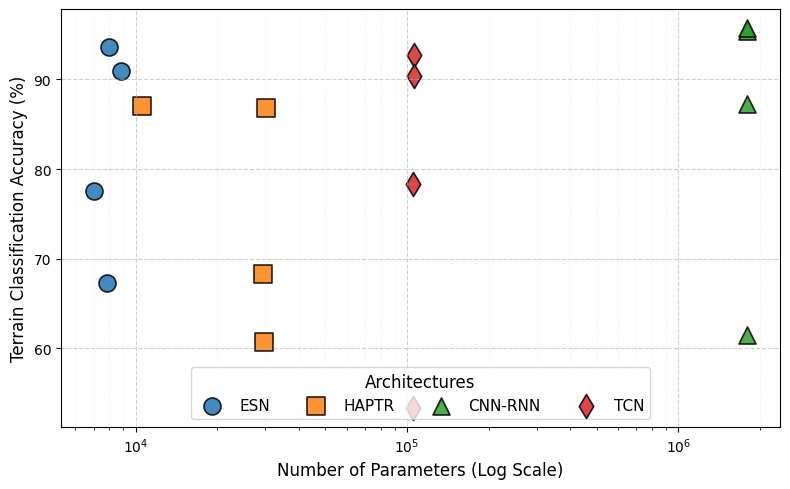

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress the StandardScaler version warnings during loading
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


# =========================================
# 1. EXTRACTING MODEL SIZES
# =========================================
model_sizes = {}

for model_arch in model_arch_list:
    arch_name = model_arch.upper()
    if model_arch == 'cnn_rnn':
        arch_name = 'CNN-RNN'
        
    model_sizes[arch_name] = []
    
    for sensor_key, model_file in zip(sensor_list, model_list):
        
        # 🚨 FIX: Restored the conditional loading for ESN models
        if model_arch in ['esn']:
            filepath = f"trained_models_w_noise/model_1_{model_arch}_{model_file}_w_cma_es_mini.pt"
        else:
            filepath = f"trained_models_w_noise/model_1_{model_arch}_{model_file}.pt"
            
        model_arch_obj_list[model_arch].load_model(filepath)
            
        size = model_arch_obj_list[model_arch].get_model_size()
        model_sizes[arch_name].append(size)

print("\n=========================================")
print("PLOTTING SIZE VS. ACCURACY SCATTER")
print("=========================================")

# 2. Setup plotting styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^'},
    'TCN': {'color': '#d62728', 'marker': 'd'},
    'STRN': {'color': '#9467bd', 'marker': 'v'}
}

fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plotting Logic
for model_name, sizes in model_sizes.items():
    
    # Extract the corresponding accuracies from your existing accuracy_dict
    model_accuracies = []
    for model_file in model_list:
        
        # Fetch the mean accuracy
        acc = accuracy_dict[model_name][model_file]['mean']
        model_accuracies.append(acc)
         
    style = styles.get(model_name, {'color': 'gray', 'marker': 'o'})
    
    # Plot the scatter points for this architecture
    scatter = ax.scatter(sizes, model_accuracies, 
                         label=model_name, 
                         color=style['color'], 
                         marker=style['marker'],
                         s=150,          # Marker size
                         alpha=0.85,     # Transparency
                         edgecolors='black', # Black border for clarity
                         linewidth=1.2)
                         
    # Optional: Annotate each point with its Configuration number
    # for i, (sz, acc) in enumerate(zip(sizes, model_accuracies)):
    #     ax.annotate(str(i+1), (sz, acc), xytext=(7, 0), textcoords='offset points', fontsize=9, va='center')

# 4. Format the Axes
ax.set_xscale('log') # CRITICAL: Log scale for massive size differences
ax.set_xlabel('Number of Parameters (Log Scale)', fontsize=12)
ax.set_ylabel('Terrain Classification Accuracy (%)', fontsize=12)

# Gridlines
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# Legend
ax.legend(title='Architectures', loc='lower center', fontsize=11, title_fontsize=12, ncol=5)

plt.tight_layout()

# Save and Show
plt.savefig('size_vs_accuracy_scatter.png', dpi=500, bbox_inches='tight')
plt.show()


[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_8_w_cma_es_mini.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 1334 neurons
   • Leak Rate:              0.5737478730102817
   • Target Classes:         6
   • Ignore Time Column:     True
   • Pooling Strategy:       'mean'

⚙️ Matrix Shapes:
   • W_in  (Input -> Res):   (1334, 53)
   • W_res (Res Dynamics):   (1334, 1334)
   • W_out (Res -> Output):  (6, 1334)

🛠️ System Config:
   • Scaler Initialized:     True
   • Expected Features:      53
   • Target Device:          CUDA
--------------------------------------------------

Total ESN Parameters (W_in, W_res, W_out): 8004 (8.00K)

[SUCCESS] ESN Model loaded from: 'trained_models_w_noise/model_1_esn_config_6_w_cma_es_mini.pt'
--------------------------------------------------
💡 Hyperparameters:
   • Reservoir Size (n_res): 1474 neurons
   • Leak Rate:              0.5093397016014699
   • Target Classe

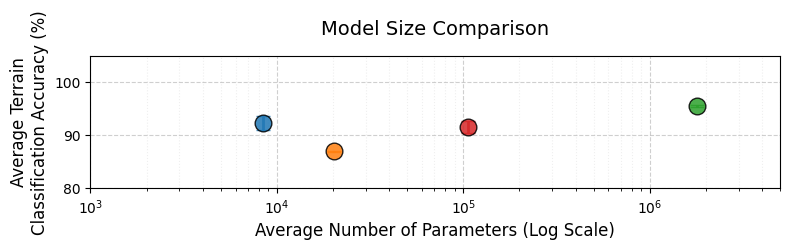

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. EXTRACTING MODEL SIZES
# =========================================
model_sizes = {}
model_list = ['config_8', 'config_6']
for model_arch in model_arch_list:
    arch_name = model_arch.upper()
    if model_arch == 'cnn_rnn':
        arch_name = 'CNN-RNN'
        
    model_sizes[arch_name] = []
    
    for sensor_key, model_file in zip(sensor_list, model_list):
        
        # 🚨 FIX: Restored the conditional loading for ESN models
        if model_arch in ['esn']:
            filepath = f"trained_models_w_noise/model_1_{model_arch}_{model_file}_w_cma_es_mini.pt"
        else:
            filepath = f"trained_models_w_noise/model_1_{model_arch}_{model_file}.pt"
            
        model_arch_obj_list[model_arch].load_model(filepath)
            
        size = model_arch_obj_list[model_arch].get_model_size()
        model_sizes[arch_name].append(size)
print(model_sizes)
print("\n=========================================")
print("PLOTTING AVG SIZE VS. AVG ACCURACY")
print("=========================================")

# 2. Setup plotting styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 'o'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': 'o'},
    'TCN': {'color': '#d62728', 'marker': 'o'},
    'STRN': {'color': '#9467bd', 'marker': 'o'}
}

fig, ax = plt.subplots(figsize=(8, 2.5))

# 3. Plotting Logic
for model_name, sizes in model_sizes.items():
    
    # Extract the corresponding accuracies from your existing accuracy_dict
    model_accuracies = []
    for model_file in model_list:
        acc = accuracy_dict[model_name][model_file]['mean']
        model_accuracies.append(acc)
         
    # --- NEW: Calculate the statistical averages across all 5 configurations ---
    avg_size = np.mean(sizes)
    avg_acc = np.mean(model_accuracies)
    std_acc = np.std(model_accuracies) # Calculate variance across configs
    
    style = styles.get(model_name, {'color': 'gray', 'marker': 'o'})
    
    # Plot using errorbar to show the mean point PLUS the variance
    ax.errorbar(avg_size, avg_acc, yerr=std_acc, 
                label=model_name, 
                color=style['color'], 
                marker=style['marker'],
                markersize=12,           # Large marker for the average point
                alpha=0.85,         
                markeredgecolor='black', # Black border for clarity
                linewidth=2,             # Thickness of the error bar
                capsize=5,               # Caps on the error bars
                linestyle='None')        # Ensure no lines connect different models

# 4. Format the Axes
ax.set_xlim(10**3, 5*10**6)  # Example: From 100 to 10 Million parameters
ax.set_ylim(80, 105)     # Example: From 0% to 105% accuracyssa

ax.set_xscale('log') # CRITICAL: Log scale for massive size differences
ax.set_xlabel('Average Number of Parameters (Log Scale)', fontsize=12)
ax.set_ylabel('Average Terrain\nClassification Accuracy (%)', fontsize=12)
ax.set_title('Model Size Comparison', fontsize=14, pad=15)

# Gridlines
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# Legend
# --- NEW: Legend without error bars ---
# 1. Get the automatically generated handles and labels
handles, labels = ax.get_legend_handles_labels()

# 2. Extract ONLY the first element of each handle (the marker), ignoring the error lines
clean_handles = [h[0] for h in handles]

# 3. Pass the cleaned handles back into the legend
# ax.legend(clean_handles, labels, title='Architectures', loc='lower center', fontsize=11, title_fontsize=12, ncol=5)
plt.tight_layout()

# Save and Show
plt.savefig('avg_size_vs_accuracy.png', dpi=500, bbox_inches='tight')
plt.show()

## Inference Time

In [73]:
# import numpy as np
# import matplotlib.pyplot as plt
# import time
# import torch

# # =========================================
# # 1. MEASURING INFERENCE TIMES
# # =========================================
# model_inference_times = {}

# print("=========================================")
# print("MEASURING INFERENCE TIMES (WITH WARM-UP)")
# print("=========================================")

# for model_arch in model_arch_list:
#     arch_name = model_arch.upper()
#     if model_arch == 'cnn_rnn':
#         arch_name = 'CNN-RNN'
#     elif model_arch in ['signal_transformer', 'strn']:
#         arch_name = 'STRN'
        
#     model_inference_times[arch_name] = []
    
#     for sensor_key, model_file in zip(sensor_list, model_list):
#         model_obj = model_arch_obj_list[model_arch]
        
#         # Load the model
#         if model_arch == 'esn':
#             model_arch_obj_list[model_arch].load_model(f"trained_models/model_1_{model_arch}_{model_file}.pt")
#             # Extract input size from ESN W_in shape (n_res, n_inputs)
#             n_inputs = model_obj.W_in.shape[1] 
#             seq_len = 100 # Default from your previous logs
#         else:
#             model_arch_obj_list[model_arch].load_model(f"trained_models/model_1_{model_arch}_{model_file}.pt")
#             n_inputs = model_obj.n_inputs
#             seq_len = model_obj.seq_len

#         # Generate a dummy input matching the sensor configuration
#         dummy_input = np.random.randn(seq_len, n_inputs).astype(np.float32)
        
#         # --- WARM-UP PHASE ---
#         # Run 10 predictions without measuring to initialize hardware/CUDA
#         for _ in range(10):
#             _ = model_obj.predict(dummy_input)
            
#         # --- MEASUREMENT PHASE ---
#         # Average the time over 100 runs for a stable metric
#         n_runs = 100
#         start_time = time.perf_counter()
        
#         for _ in range(n_runs):
#             _ = model_obj.predict(dummy_input)
            
#         # If using GPU, wait for operations to finish before stopping the clock
#         if hasattr(model_obj, 'device') and model_obj.device.type == 'cuda':
#             torch.cuda.synchronize()
            
#         end_time = time.perf_counter()
        
#         # Calculate average inference time in milliseconds (ms)
#         avg_time_ms = ((end_time - start_time) / n_runs) * 1000
#         model_inference_times[arch_name].append(avg_time_ms)
        
#         print(f"[{arch_name}] {model_file}: {avg_time_ms:.2f} ms")


# print("\n=========================================")
# print("PLOTTING AVG INFERENCE TIME VS. ACCURACY")
# print("=========================================")

# # 2. Setup plotting styles
# styles = {
#     'ESN': {'color': '#1f77b4', 'marker': 'o'},
#     'HAPTR': {'color': '#ff7f0e', 'marker': 's'},
#     'CNN-RNN': {'color': '#2ca02c', 'marker': '^'},
#     'TCN': {'color': '#d62728', 'marker': 'd'},
#     'STRN': {'color': '#9467bd', 'marker': 'v'}
# }

# fig, ax = plt.subplots(figsize=(8, 6))

# # 3. Plotting Logic
# for model_name, inf_times in model_inference_times.items():
    
#     # Extract the corresponding accuracies
#     model_accuracies = []
#     for model_file in model_list:
        
#         acc = accuracy_dict[model_name][model_file]['mean']
#         model_accuracies.append(acc)
         
#     # Calculate statistical averages and variance across all 5 configurations
#     avg_inf_time = np.mean(inf_times)
#     std_inf_time = np.std(inf_times) # Optional: X-axis variance
    
#     avg_acc = np.mean(model_accuracies)
#     std_acc = np.std(model_accuracies) # Y-axis variance
    
#     style = styles.get(model_name, {'color': 'gray', 'marker': 'o'})
    
#     # Plot using errorbar to show variance in both Time (X) and Accuracy (Y)
#     ax.errorbar(avg_inf_time, avg_acc, 
#                 xerr=std_inf_time,   # Shows how much inference time changes between 48 channels vs 4 channels
#                 yerr=std_acc,        # Shows how much accuracy drops across configurations
#                 label=model_name, 
#                 color=style['color'], 
#                 marker=style['marker'],
#                 markersize=12,           
#                 alpha=0.85,         
#                 markeredgecolor='black', 
#                 linewidth=2,             
#                 capsize=5,               
#                 linestyle='None')        

# # ==========================================
# # 4. Format the Axes & Legend
# # ==========================================
# # Depending on your hardware, inference times might range from 0.1ms to 50ms.
# # You can change this to 'linear' if the models run at relatively similar speeds.
# # ax.set_xscale('log') 

# # Adjust X limits based on your actual measurements (e.g., 0.1ms to 100ms)
# # ax.set_xlim(0.1, 100)  
# ax.set_ylim(80, 105)        

# ax.set_xlabel('Average Inference Time per Gait Cycle (ms, Log Scale)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Average Terrain Classification Accuracy (%)', fontsize=12, fontweight='bold')
# ax.set_title('Average Accuracy vs. Inference Time Trade-off\n(Aggregated Across 5 Sensor Configurations)', fontsize=13, pad=15, fontweight='bold')

# # Gridlines
# ax.grid(True, which='major', linestyle='--', alpha=0.6)
# ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# # --- Clean Legend without error bars ---
# handles, labels = ax.get_legend_handles_labels()
# clean_handles = [h[0] for h in handles]
# ax.legend(clean_handles, labels, title='Architectures', loc='lower right', fontsize=11, title_fontsize=12)

# plt.tight_layout()

# # Save and Show
# # plt.savefig('inference_vs_accuracy_scatter.png', dpi=500, bbox_inches='tight')
# plt.show()

While the Echo State Network (ESN) requires drastically fewer trainable parameters (only the readout weights) and offers rapid training times, it does not guarantee faster inference in deployment. Our results demonstrate that the ESN's inference latency is heavily bottlenecked by the sequential dense matrix multiplications of its large, fixed reservoir (e.g., 500 neurons). Conversely, modern deep learning architectures like the CNN-RNN benefit from massively parallelized convolutional layers and highly optimized hardware-level kernels (cuDNN), allowing them to process the same temporal gait cycle with lower inference latency despite having more trainable weights.